# 01 Test SSIM

This notebook tests the SSIM baseline method on the payload loss test dataset. SSIM compares each frame against the initial reference frame and produces a similarity score, where lower scores indicate larger visual changes.

## 1. Imports and setup

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.utils import GROUND_TRUTH_CSV, resolve_test_video_path
from src.ssim_method import SSIMMethod
from src.evaluate import evaluate_method

## 2. Load Ground Truth

Load the test dataset annotations from `ground_truth.csv`.

In [2]:
gt = pd.read_csv(GROUND_TRUTH_CSV)
gt.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411


## 3. Inspect One Video

Select one video from the dataset and run SSIM on it to check whether the score drops around the payload loss event.

In [3]:
# Pick one video to inspect
row = gt.iloc[0]
video_path = resolve_test_video_path(row["filename"])

row, video_path

(filename         videos_normal/indoor_full/front_empty_001.mp4
 camera_id                                                front
 is_loss_event                                                0
 loss_frame                                                  -1
 total_frames                                               410
 Name: 0, dtype: object,
 PosixPath('/Users/tohjiale/Desktop/payload_loss_detection/test_data/videos_normal/indoor_full/front_empty_001.mp4'))

## 4. Test SSIM on one video

In [5]:
method = SSIMMethod(threshold=0.85, consecutive_frames=5)
result = method.predict_video(video_path)

print("Detected frame:", result["detected_frame"])
print("Ground truth loss frame:", row["loss_frame"])

Detected frame: -1
Ground truth loss frame: -1


## 5. Plot SSIM Score

The plot shows the SSIM score over time. A lower score means the current frame differs more from the reference frame.

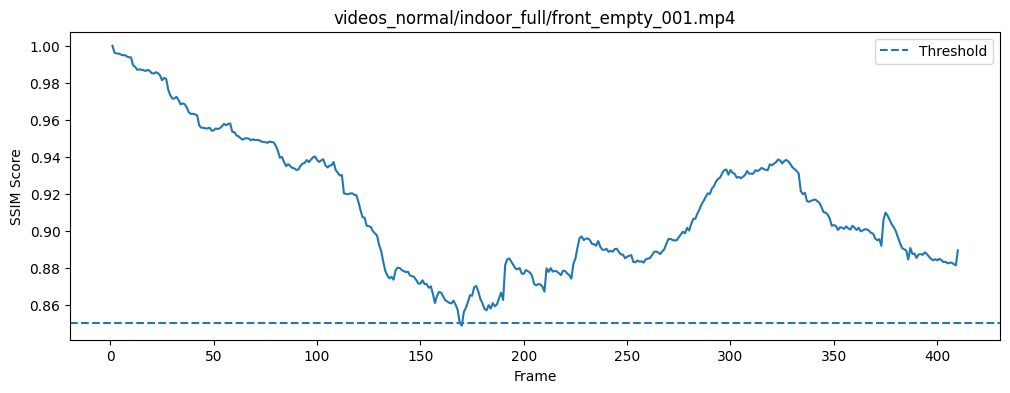

In [6]:
frames = list(range(1, len(result["scores"]) + 1))

plt.figure(figsize=(12, 4))
plt.plot(frames, result["scores"])
plt.axhline(method.threshold, linestyle="--", label="Threshold")

if row["is_loss_event"] == 1:
    plt.axvline(row["loss_frame"], linestyle="--", label="Ground Truth Loss Frame")

if result["detected_frame"] != -1:
    plt.axvline(result["detected_frame"], linestyle=":", label="Detected Frame")

plt.xlabel("Frame")
plt.ylabel("SSIM Score")
plt.title(row["filename"])
plt.legend()
plt.show()

## 6. Evaluate SSIM on Full Test Dataset

Run SSIM on all test videos and compute event-level, frame-level, and latency metrics.

In [7]:
method = SSIMMethod(threshold=0.85, consecutive_frames=5)

video_results, frame_results, metrics = evaluate_method(method)

metrics

{'event_level_recall': np.float64(0.5),
 'event_level_precision': np.float64(0.2647058823529412),
 'frame_level_precision': np.float64(0.39065730935522275),
 'avg_detection_delay_frames': np.float64(-11.916666666666666),
 'avg_latency_ms': np.float64(0.5375620752139878)}

### Video-Level Results

Preview of evaluation results at the video level, including detected frame and ground truth labels.

In [8]:
video_results.head()

,filename,camera_id,is_loss_event,loss_frame,total_frames,detected_frame
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,410,-1
1,videos_normal/indoor_full/back_empty_001.mp4,back,0,-1,408,168
2,videos_normal/indoor_full/left_empty_001.mp4,left,0,-1,406,168
3,videos_normal/indoor_full/right_empty_001.mp4,right,0,-1,404,185
4,videos_normal/indoor_med/front_empty_001.mp4,front,0,-1,411,35


### Frame-Level Results

Preview of per-frame predictions, scores, and inference latency for all videos.

In [9]:
frame_results.head()

,filename,camera_id,is_loss_event,loss_frame,frame_idx,score,pred_frame_loss,inference_time_ms
0,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,1,1.000000,0,0.100166
1,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,2,0.996256,0,1.554958
2,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,3,0.995816,0,1.314167
3,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,4,0.995754,0,1.369917
4,videos_normal/indoor_full/front_empty_001.mp4,front,0,-1,5,0.995279,0,1.304750


## 7. Threshold Sweep

SSIM requires a threshold to decide when visual change is large enough to indicate payload loss. This section tests thresholds from 0.50 to 0.95, in steps of 0.05, and compares their metrics.

In [10]:
# Threshold sweep

sweep_results = []

thresholds = [round(x, 2) for x in list(pd.Series([0.50 + i * 0.05 for i in range(10)]))]

for threshold in thresholds:
    method = SSIMMethod(threshold=threshold, consecutive_frames=5)
    _, _, metrics = evaluate_method(method)

    sweep_results.append({
        "threshold": threshold,
        **metrics
    })

sweep_df = pd.DataFrame(sweep_results)
sweep_df

,threshold,event_level_recall,event_level_precision,frame_level_precision,avg_detection_delay_frames,avg_latency_ms
0,0.50,0.319444,0.287500,0.239172,-12.782609,0.543188
1,0.55,0.361111,0.298851,0.271164,-17.576923,0.534256
2,0.60,0.333333,0.269663,0.298906,-19.250000,0.519614
3,0.65,0.305556,0.239130,0.315819,-11.681818,0.555964
4,0.70,0.375000,0.259615,0.323756,-2.777778,0.536881
5,0.75,0.472222,0.290598,0.335249,-3.500000,0.555352
6,0.80,0.513889,0.293651,0.353561,-0.702703,0.561924
7,0.85,0.500000,0.264706,0.390657,-11.916667,0.556729
8,0.90,0.194444,0.097222,0.384479,-11.285714,0.544073
9,0.95,0.000000,0.000000,0.367272,NaN,0.551092


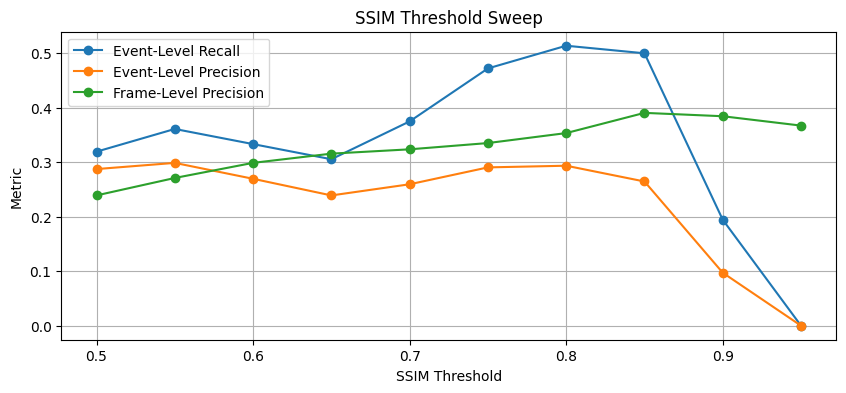

In [16]:
# Plot threshold sweep

plt.figure(figsize=(10, 4))
plt.plot(sweep_df["threshold"], sweep_df["event_level_recall"], marker="o", label="Event-Level Recall")
plt.plot(sweep_df["threshold"], sweep_df["event_level_precision"], marker="o", label="Event-Level Precision")
plt.plot(sweep_df["threshold"], sweep_df["frame_level_precision"], marker="o", label="Frame-Level Precision")

plt.xlabel("SSIM Threshold")
plt.ylabel("Metric")
plt.title("SSIM Threshold Sweep")
plt.legend()
plt.grid(True)
# plt.savefig("results/fig9_ssim_threshold_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Consecutive Frame Filtering

This tests how requiring multiple consecutive loss predictions affects false positives and detection reliability.

In [14]:
# Sweep consecutive frame filtering

filter_results = []

for consecutive_frames in [1, 3, 5, 10, 15, 30]:
    method = SSIMMethod(threshold=0.80, consecutive_frames=consecutive_frames)
    _, _, metrics = evaluate_method(method)

    filter_results.append({
        "consecutive_frames": consecutive_frames,
        **metrics
    })

filter_df = pd.DataFrame(filter_results)
filter_df

,consecutive_frames,event_level_recall,event_level_precision,frame_level_precision,avg_detection_delay_frames,avg_latency_ms
0,1,0.555556,0.305344,0.354228,-5.025000,0.706595
1,3,0.513889,0.293651,0.353674,-3.432432,0.713991
2,5,0.513889,0.293651,0.353561,-0.702703,0.712760
3,10,0.513889,0.296000,0.353797,3.594595,0.720051
4,15,0.513889,0.300813,0.354368,7.243243,0.718945
5,30,0.513889,0.310924,0.357200,12.540541,0.727752


## 9. Save Results

Save SSIM results for later comparison with YOLO26n and the Siamese network.

In [13]:
output_dir = PROJECT_ROOT / "notebooks" / "results"
output_dir.mkdir(exist_ok=True)

video_results.to_csv(output_dir / "ssim_video_results.csv", index=False)
frame_results.to_csv(output_dir / "ssim_frame_results.csv", index=False)
sweep_df.to_csv(output_dir / "ssim_threshold_sweep.csv", index=False)
filter_df.to_csv(output_dir / "ssim_filter_sweep.csv", index=False)

print("Saved SSIM results.")

Saved SSIM results.


## 10. Conclusion

SSIM performance is generally weak across all tested thresholds. While a threshold of 0.80 provides the best overall balance, achieving an event-level recall of 51.4% and frame-level precision of 35.4%, the results remain insufficient for reliable payload loss detection. Event-level precision is also low at 29.4%, indicating a high number of false positives.

Across thresholds, SSIM struggles to maintain both high recall and precision simultaneously. Lower thresholds improve recall but introduce more false positives, while higher thresholds reduce false positives at the cost of missing many loss events entirely. Although detection delay is generally low (close to the annotated loss frame), the inconsistency in detection performance limits its practical use.

Overall, despite its low computational cost and fast inference time (~0.55 ms per frame), SSIM is not robust enough for this application due to its sensitivity to lighting changes, shadows, and small visual variations.